In [18]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [ ]:
data_dir = Path("data")
INDIR = Path("../data/data_model")

In [ ]:
ano = 2021
arquivo = INDIR / f"ANALISE_NOTAS_ENEM_MUNICIPIOS_BRASIL_CLUSTERS_{ano}.csv"
df = pd.read_csv(arquivo, sep=",")

In [21]:
df.head()

,NO_MUNICIPIO_PROVA,UF,QTD_PARTICIPANTES,NU_NOTA_CN_MEDIA,NU_NOTA_CH_MEDIA,NU_NOTA_LC_MEDIA,NU_NOTA_MT_MEDIA,NU_NOTA_REDACAO_MEDIA,RENDA_FAMILIAR_SM_MEDIA,CLUSTER
0,ABAETETUBA,PA,3420,460.132427,481.725731,460.382924,479.531871,596.894737,1.407595,0
1,ABAETÉ,MG,487,498.409035,521.487885,510.125462,548.994456,638.193018,2.413321,2
2,ABREU E LIMA,PE,1355,470.625092,496.747306,485.631365,500.050480,580.693727,1.606974,1
3,ACARAPE,CE,310,461.340323,480.222258,471.069355,486.998387,586.322581,1.199248,1
4,ACARAÚ,CE,971,454.735324,473.678888,471.117199,500.697837,563.995881,1.080156,0


In [22]:
df_dict = {
    0: df[df['CLUSTER'] == 0].copy().reset_index(drop=True),
    1: df[df['CLUSTER'] == 1].copy().reset_index(drop=True),
    2: df[df['CLUSTER'] == 2].copy().reset_index(drop=True)
}

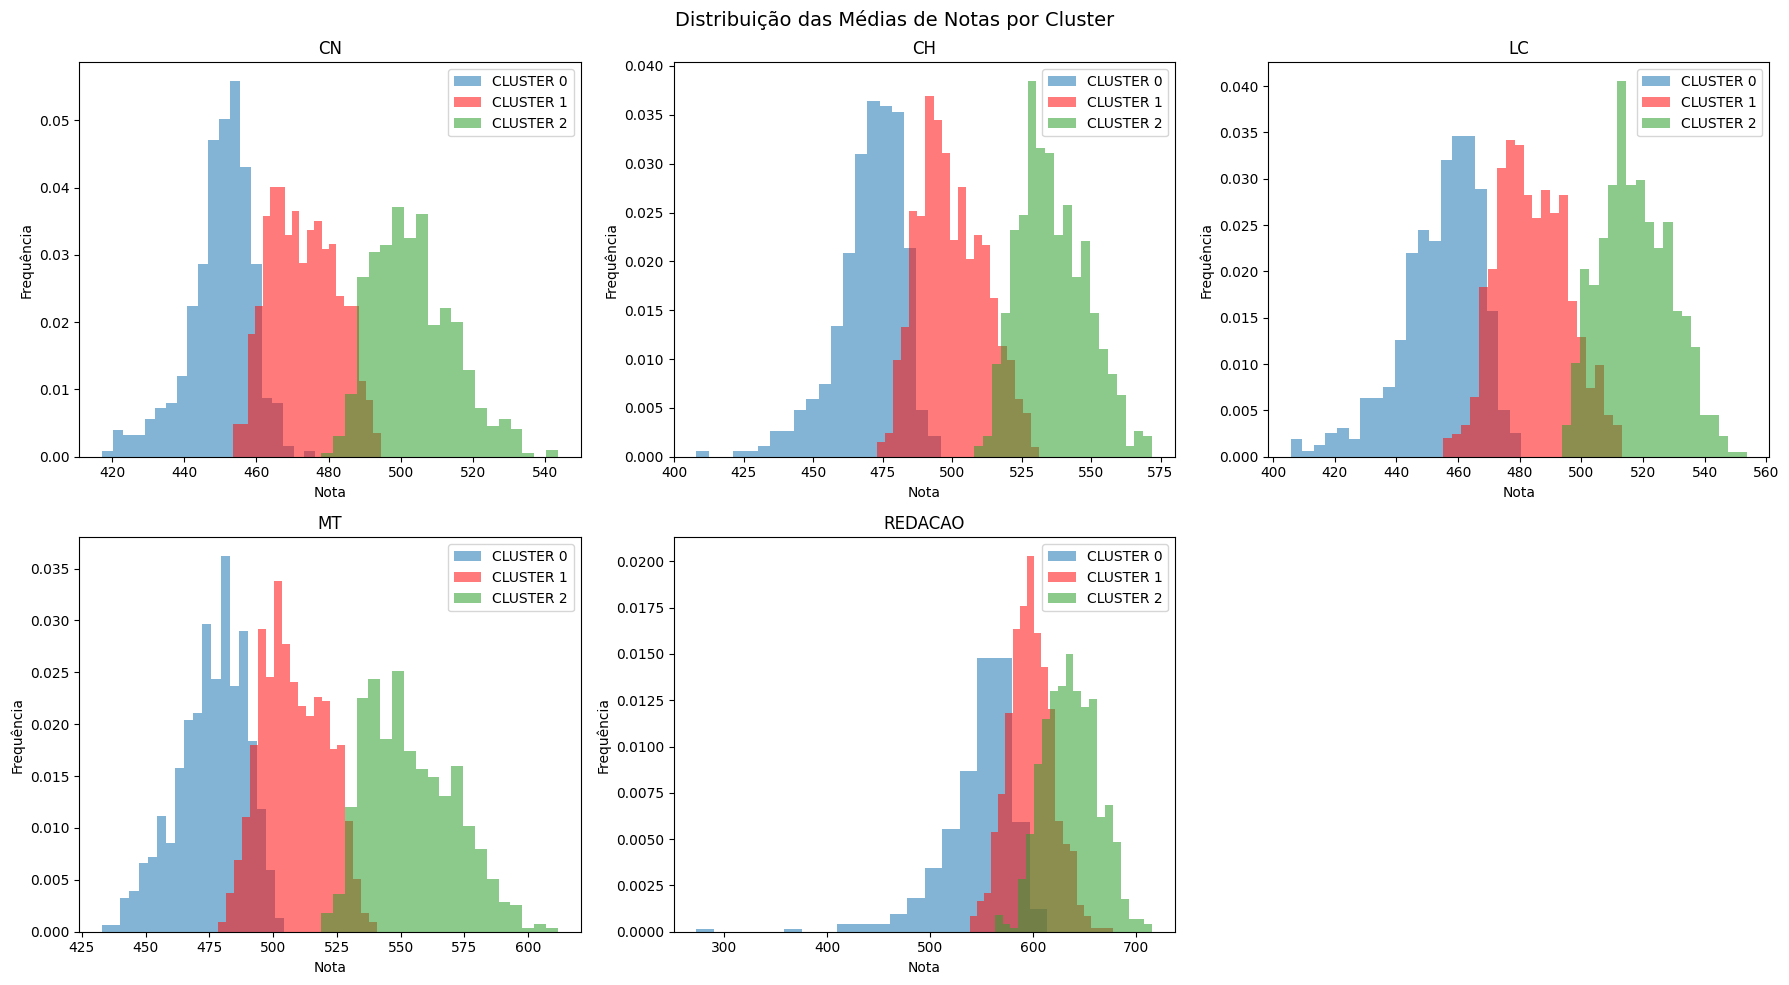

In [23]:
colunas_notas = [c for c in df.columns if c.startswith("NU_NOTA_") and c.endswith("_MEDIA")]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cores_cluster = {0: "#1f77b4", 1: "#ff0e0e", 2: "#2ca02c"}

for i, coluna in enumerate(colunas_notas):
    ax = axes[i]
    for cluster in sorted(df["CLUSTER"].unique()):
        ax.hist(
            df.loc[df["CLUSTER"] == cluster, coluna],
            bins=20,
            alpha=0.55,
            label=f"CLUSTER {cluster}",
            color=cores_cluster.get(cluster, None),
            density=True
        )
    ax.set_title(coluna.replace("NU_NOTA_", "").replace("_MEDIA", ""))
    ax.set_xlabel("Nota")
    ax.set_ylabel("Frequência")
    ax.legend()

for j in range(len(colunas_notas), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribuição das Médias de Notas por Cluster", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:


renda_col = "RENDA_FAMILIAR_SM_MEDIA"

titulos = [c.replace("NU_NOTA_", "").replace("_MEDIA", "") for c in colunas_notas]

fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=titulos + [""],
    horizontal_spacing=0.08,
    vertical_spacing=0.12
)

for i, coluna in enumerate(colunas_notas):
    row = i // 3 + 1
    col = i % 3 + 1

    for cluster in sorted(df["CLUSTER"].unique()):
        dados = df[df["CLUSTER"] == cluster]

        fig.add_trace(
            go.Scatter(
                x=dados[renda_col],
                y=dados[coluna],
                mode="markers",
                marker=dict(size=6, color=cores_cluster.get(cluster)),
                opacity=0.7,
                name=f"CLUSTER {cluster}",
                showlegend=(i == 0),

                customdata=dados[["NO_MUNICIPIO_PROVA", "UF"]],
                hovertemplate=(
                    "Município: %{customdata[0]} (%{customdata[1]})<br>"
                    "Renda: %{x:.2f}<br>"
                    "Nota: %{y:.2f}<br>"
                    "Cluster: " + str(cluster) +
                    "<extra></extra>"
                )
            ),
            row=row,
            col=col
        )

    fig.update_xaxes(title_text="Renda Familiar Média (SM)", row=row, col=col)
    fig.update_yaxes(title_text="Nota Média", row=row, col=col)

fig.update_layout(
    title="Relação entre Renda Familiar Média e Notas por Cluster",
    height=800,
    width=1200,
    template="plotly_white"
)

fig.show()